In [7]:
import pandas as pd
import numpy as np

bank = pd.read_csv("bank_profiles.csv")
loan = pd.read_csv("loan_portfolio.csv")
macro_scenario = pd.read_csv("macro_scenarios.csv")
macro_stress = pd.read_csv("macro_stress_scenarios.csv")
panel = pd.read_csv("bank_stress_simulated_panel.csv")

confirming the shape of each variable to get the idea moving forward

In [8]:
for name, df in [("bank", bank), ("loan", loan), ("macro_scenario", macro_scenario),
                  ("macro_stress", macro_stress), ("panel", panel)]:
    print(name, df.shape)

bank (42, 20)
loan (3006, 7)
macro_scenario (504, 9)
macro_stress (60, 11)
panel (20025, 24)


Checking the dtypes for the bank

In [13]:
bank.head()
bank.info()


<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   bank_id                       42 non-null     str    
 1   size_tier                     42 non-null     str    
 2   total_assets_usd              42 non-null     str    
 3   total_loans_usd               42 non-null     float64
 4   deposit_base_usd              42 non-null     float64
 5   baseline_car_pct              40 non-null     str    
 6   baseline_liquidity_ratio_pct  42 non-null     str    
 7   baseline_roa_pct              39 non-null     str    
 8   sector_concentration          42 non-null     str    
 9   bank_risk_factor              42 non-null     float64
 10  sector_wt_Technology          42 non-null     float64
 11  sector_wt_Healthcare          42 non-null     float64
 12  sector_wt_Real_Estate         42 non-null     float64
 13  sector_wt_Energy  

### `bank_profiles.csv` — dtype & missing value checks

- **`total_assets_usd`** — dtype `str`, should be `float64`. A dollar figure; currency symbols/commas are forcing it to be read as text.
- **`baseline_liquidity_ratio_pct`** — dtype `str`, should be `float64`. A percentage column; likely a `%` symbol is forcing text.
- **`baseline_car_pct`** — dtype `str`. Only 40/42 non-null, so pandas already flags 2 rows as missing — but since the column is text, there may be more disguised missing values (e.g. `"NA"`, `"unknown"`) not recognized as null.
- **`baseline_roa_pct`** — dtype `str`, 39/42 non-null (3 recognized as missing). Needs the same check as above — could have additional disguised missing values beyond the 3 real NaNs.
- **`sector_concentration`** — categorical text column. Needs a `value_counts()` pass to check for spelling/casing inconsistencies.

In [14]:
print(bank["total_assets_usd"].unique()[:15])
print(bank["baseline_liquidity_ratio_pct"].unique()[:15])
print(bank["baseline_car_pct"].value_counts(dropna=False).head(15))
print(bank["baseline_roa_pct"].value_counts(dropna=False).head(15))
print(bank["sector_concentration"].value_counts(dropna=False))

<StringArray>
[ '32427758012.0',  '22127519267.0',  '49861173736.0',  '27001020572.0',
   '2782358312.0',  '99469276659.0',  '18384768014.0',  '11790860111.0',
 '$4,116,788,569',  '22889624802.0',   '6574907650.0',  '73180096007.0',
  '30350609520.0',  '81459034287.0',  '29038933937.0']
Length: 15, dtype: str
<StringArray>
['131.72444662718556', '118.03029030981152', '115.21288745053953',
 '123.14097134890687',  '151.5818251282087', '119.02563196139764',
            '144.12%',  '115.2365251205067', '121.04933596712488',
 '106.05152353399448',  '128.2778057074539',  '146.5792118087398',
   '73.3276776030339',  '109.3219952325289',  '97.65231774020783']
Length: 15, dtype: str
baseline_car_pct
NaN                   2
14.698053425364172    2
13.831304096288818    2
13.79295551718901     1
14.697693196151016    1
16.383202004377647    1
13.810658251899817    1
9.80969021814416      1
-                     1
11.025187544934033    1
unknown               1
13.61978246854657     1
13.629660431

In [24]:
# bank_id format check
print(bank["bank_id"].tolist())
print("Duplicate rows:", bank.duplicated().sum())
print(bank[bank.duplicated(keep=False)])



['BANK_001', 'BANK_002', 'BANK_003', 'BANK_004', 'BANK_005', 'BANK_006', 'BANK_007', 'BANK_008', 'BANK_009', 'BANK_010', 'BANK_011', 'BANK_012', 'BANK_013', 'BANK_014', 'BANK_015', 'BANK_016', 'BANK_017', ' BANK_018 ', 'BANK_019', 'BANK_020', 'BANK_021', 'BANK_022', 'BANK_023', 'BANK_024', 'BANK_025', 'BANK_026', 'BANK_027', 'BANK_028', 'BANK_029', 'BANK_030', 'BANK031', 'BANK_032', 'bank-033', 'BANK_034', 'BANK035', 'bank-036', 'BANK_037', 'BANK_038', 'BANK_039', 'BANK_040', 'BANK_039', 'BANK_016']
Duplicate rows: 2
     bank_id size_tier total_assets_usd  total_loans_usd  deposit_base_usd  \
15  BANK_016     small     9849974036.0     5.795240e+09      6.630720e+09   
38  BANK_039     small     9294356121.0     5.377344e+09      7.571383e+09   
40  BANK_039     small     9294356121.0     5.377344e+09      7.571383e+09   
41  BANK_016     small     9849974036.0     5.795240e+09      6.630720e+09   

      baseline_car_pct baseline_liquidity_ratio_pct    baseline_roa_pct  \
15  14.6980

### `bank_profiles.csv` — bank_id format & duplicate row checks

- **`bank_id`** — printed the full list of IDs to check formatting consistency (expected pattern: `BANK_0XX`). Needed since `bank_id` is the join key to `panel`; any mismatch would silently break the merge for that bank.
- **Duplicate rows** — checked `bank.duplicated().sum()` for exact duplicate rows, then printed the full duplicate rows (`keep=False`) to inspect which banks are affected. Matters because duplicated rows double-count a bank in any aggregation.

In [25]:
print(bank["sector_concentration"].value_counts(dropna=False))

sector_concentration
diversified      17
concentrated     16
Diversified       3
concentrated      2
DIVERSIFIED       2
concentratd       1
Concentrated      1
Name: count, dtype: int64


did `value_counts(dropna=False)` to check for spelling/casing inconsistencies across categories, since this column likely feeds into the diversified-vs-concentrated stress comparison.

In [31]:

panel.info()

<class 'pandas.DataFrame'>
RangeIndex: 20025 entries, 0 to 20024
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   bank_id                       20025 non-null  str    
 1   scenario_id                   20025 non-null  str    
 2   size_tier                     20025 non-null  str    
 3   sector_concentration          20025 non-null  str    
 4   total_assets_usd              20025 non-null  float64
 5   total_loans_usd               20025 non-null  float64
 6   baseline_car_pct              20025 non-null  float64
 7   baseline_liquidity_ratio_pct  20025 non-null  float64
 8   baseline_roa_pct              20025 non-null  float64
 9   gdp_shock_pp                  20025 non-null  float64
 10  unemp_shock_pp                20025 non-null  float64
 11  rate_shock_pp                 20025 non-null  float64
 12  credit_spread_bps             20025 non-null  float64
 13  inflation_sh

In [32]:
print(panel.dtypes)

bank_id                             str
scenario_id                         str
size_tier                           str
sector_concentration                str
total_assets_usd                float64
total_loans_usd                 float64
baseline_car_pct                float64
baseline_liquidity_ratio_pct    float64
baseline_roa_pct                float64
gdp_shock_pp                    float64
unemp_shock_pp                  float64
rate_shock_pp                   float64
credit_spread_bps               float64
inflation_shock_pp              float64
fx_devaluation_pct              float64
scenario_severity                   str
weighted_pd_multiplier          float64
projected_npl_ratio_pct         float64
stressed_el_rate_pct            float64
incremental_credit_loss_usd         str
car_after_pct                       str
roa_after_pct                   float64
liquidity_after_pct                 str
bank_condition                      str
dtype: object


### `bank_stress_simulated_panel.csv` — dtype checks

- **`car_after_pct`** — dtype `str`, should be numeric. Critical output column — this is the actual regulatory pass/fail check (CAR vs minimum threshold) the project is built around.
- **`incremental_credit_loss_usd`** — dtype `str`, should be numeric. Headline loss figure.
- **`liquidity_after_pct`** — dtype `str`, already showed missing values earlier — needs the same non-numeric-character check.
- **`roa_after_pct`** — dtype `float64`, no type issue. Still worth a `describe()` — numeric dtype doesn't guarantee sane values, need to check the range makes sense for an ROA percentage.
- **`scenario_severity`, `bank_condition`, `size_tier`, `sector_concentration`** — all dtype `str`, all categorical. Each needs a `value_counts(dropna=False)` pass to check for casing/typo fragmentation, same as done for `bank_profiles`.

In [33]:
mask_car = panel["car_after_pct"].astype(str).str.contains(r"[^\d\.\-]", regex=True, na=False)
print(f"car_after_pct: {mask_car.sum()} rows with non-numeric characters")
print(panel.loc[mask_car, "car_after_pct"].unique()[:15])

mask_loss = panel["incremental_credit_loss_usd"].astype(str).str.contains(r"[^\d\.\-]", regex=True, na=False)
print(f"\nincremental_credit_loss_usd: {mask_loss.sum()} rows with non-numeric characters")
print(panel.loc[mask_loss, "incremental_credit_loss_usd"].unique()[:15])

car_after_pct: 56 rows with non-numeric characters
<StringArray>
['MISSING', ' ', 'missing', 'unknown']
Length: 4, dtype: str

incremental_credit_loss_usd: 120 rows with non-numeric characters
<StringArray>
[   '$13,119,776',    '$27,840,047', '$1,158,548,044',   '$616,822,037',
    '$23,724,990',   '$403,921,085',   '$161,692,984',   '$130,375,081',
   '$124,988,789',    '$24,026,486',    '$58,073,077',   '$131,092,306',
    '$83,972,216',    '$39,212,091',   '$278,846,667']
Length: 15, dtype: str


In [34]:
print("car_after_pct true NaN (before regex check):", panel["car_after_pct"].isna().sum())

car_after_pct true NaN (before regex check): 74


### `car_after_pct` — missing value summary

- **74** true `NaN` + **56** disguised text tokens (`'MISSING'`, `'missing'`, `'unknown'`, `' '`) = **130 total missing values** (~0.65% of 20,025 rows).
- Small as a percentage, but this is the critical regulatory pass/fail column — need to decide and document a handling strategy: drop, impute, or flag separately as "unable to assess" rather than silently excluding from pass/fail stats.

In [35]:
mask_liq = panel["liquidity_after_pct"].astype(str).str.contains(r"[^\d\.\-]", regex=True, na=False)
print(f"liquidity_after_pct: {mask_liq.sum()} rows with non-numeric characters")
print(panel.loc[mask_liq, "liquidity_after_pct"].unique())

liquidity_after_pct: 60 rows with non-numeric characters
<StringArray>
['unknown', 'TBD']
Length: 2, dtype: str


In [39]:
print("liquidity_after_pct true NaN:", panel["liquidity_after_pct"].isna().sum())
liq_numeric = pd.to_numeric(panel["liquidity_after_pct"], errors="coerce")
print(liq_numeric.describe())
print("\nRows below 0:", (liq_numeric < 0).sum())
print(liq_numeric[liq_numeric < 0].unique())

liquidity_after_pct true NaN: 69
count    19896.000000
mean       103.201778
std         23.071143
min         -1.000000
25%         89.040000
50%        104.810000
75%        119.152500
max        158.090000
Name: liquidity_after_pct, dtype: float64

Rows below 0: 21
[-1.]


### `liquidity_after_pct` — missing value summary

- **69** true `NaN` + **60** disguised text tokens (`'unknown'`, `'TBD'`) + **21** fake sentinel values (`-1`, physically impossible for a liquidity ratio) = **150 total missing values** (~0.75% of 20,025 rows).
- The `-1` sentinel wouldn't have been caught by a symbol/text check alone — only surfaced by checking the numeric range (`min` came out negative, which isn't physically valid).

In [40]:
print(panel["roa_after_pct"].describe())

count    20025.000000
mean         0.427877
std          2.591083
min        -70.000000
25%         -0.070000
50%          0.450000
75%          0.890000
max        166.000000
Name: roa_after_pct, dtype: float64


In [41]:
extreme = panel[(panel["roa_after_pct"] < -10) | (panel["roa_after_pct"] > 10)]
print("Rows with implausible ROA:", len(extreme))
print(extreme["roa_after_pct"].tolist())

Rows with implausible ROA: 15
[-24.0, 142.0, 119.0, 153.0, 34.0, 48.0, 63.0, 72.0, -35.0, 27.0, 166.0, 57.99999999999999, 21.0, -70.0, 128.0]


### `roa_after_pct` — implausible value check

- **15 rows** with implausible ROA values (e.g. `-70.0`, `142.0`, `166.0`) — way outside a realistic ROA range.
- Dividing all 15 by 100 lands them right back in the normal distribution (median 0.45%, most values between -0.07% and 0.89%) — a consistent decimal-point-shift error, not random noise.
- One value (`57.99999999999999`) shows a floating-point tail typical of `value * 100` in code — suggests the error was introduced systematically, not as 15 manual typos.
- **Fix:** divide these 15 rows by 100 — not a drop/impute case, since the true value is recoverable.

In [42]:
print(panel["bank_condition"].value_counts(dropna=False))

bank_condition
Healthy      10147
Stressed      6471
Critical      3107
Helathy         51
HEALTHY         41
healthy         34
Healthy         30
stressed        28
Stresed         27
 Stressed       21
STRESSED        20
Critcal         16
critical        11
Critical        11
CRITICAL        10
Name: count, dtype: int64


### `bank_condition` — target label fragmentation (highest priority fix)

- 3 real categories (`Healthy`, `Stressed`, `Critical`) fragmented into **13 variants** via casing, typos, and whitespace.
- ~10,303 Healthy, ~6,567 Stressed, ~3,155 Critical once consolidated.
- Critical to fix before any modeling or aggregation — as-is, this creates phantom classes and silently corrupts class proportions and any classifier trained on this label.

In [43]:
print(panel["scenario_severity"].value_counts(dropna=False))

scenario_severity
severe       5057
adverse      4948
moderate     4870
mild         3872
baseline     1028
sever          39
Moderate       33
advers         31
Severe         31
Adverse        30
 mild          26
Mild           24
moderat        24
baseline        6
Baseline        6
Name: count, dtype: int64


### `scenario_severity` (panel) — category fragmentation

- 5 real severity tiers (`baseline`, `mild`, `moderate`, `adverse`, `severe`) fragmented into 15 variants via casing, typos, and whitespace.
- Same issue type as `bank_condition` — matters here because this column is how we will be slice outcomes by severity (e.g. "average CAR drop under severe vs moderate scenarios"); fragmented categories would understate real group sizes and weaken any severity-based comparison.

In [44]:
print(panel["size_tier"].value_counts(dropna=False))
print("\n", panel["sector_concentration"].value_counts(dropna=False))

size_tier
medium    9014
small     7007
large     4004
Name: count, dtype: int64

 sector_concentration
concentrated    10017
diversified     10008
Name: count, dtype: int64


In [45]:
print("Duplicate rows in panel:", panel.duplicated().sum())

Duplicate rows in panel: 25


### `panel` — duplicate rows

- 25 exact duplicate rows out of 20,025 — each represents a bank×scenario combination counted twice.
- Same handling as `bank_profiles`: drop before any aggregation, since duplicates double-weight those specific bank/scenario outcomes in your stress-test summary stats.

Temporary Clean up through making copy, just for plotting

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

panel_plot = panel.copy()

# Consolidate bank_condition
condition_map = {'healthy':'Healthy','helathy':'Healthy','stressed':'Stressed',
                  'stresed':'Stressed','critical':'Critical','critcal':'Critical'}
panel_plot['bank_condition_clean'] = (panel_plot['bank_condition']
    .str.strip().str.lower().map(condition_map))

# Consolidate scenario_severity, and set a logical order for plotting
severity_map = {'baseline':'baseline','mild':'mild','moderate':'moderate','moderat':'moderate',
                'adverse':'adverse','advers':'adverse','severe':'severe','sever':'severe'}
panel_plot['scenario_severity_clean'] = (panel_plot['scenario_severity']
    .str.strip().str.lower().map(severity_map))
severity_order = ['baseline', 'mild', 'moderate', 'adverse', 'severe']

# Numeric conversion for car_after_pct — replace known missing tokens, then coerce
panel_plot['car_after_pct_clean'] = pd.to_numeric(
    panel_plot['car_after_pct'].replace(['MISSING','missing','unknown',' '], pd.NA),
    errors='coerce'
)

Does severity actually move the capital ratio the way it should?

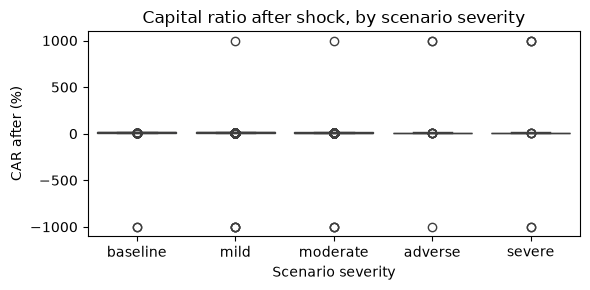

In [58]:
plt.figure(figsize=(6,3))
sns.boxplot(data=panel_plot, x='scenario_severity_clean', y='car_after_pct_clean', order=severity_order)
plt.title('Capital ratio after shock, by scenario severity')
plt.xlabel('Scenario severity'); plt.ylabel('CAR after (%)')
plt.tight_layout()
plt.show()

### Plotting 

- Boxplot of `car_after_pct` by scenario severity showed extreme outliers around +1000 and -1000, squashing the real distribution into a flat line near 0.
- Root cause: the quick cleanup only replaced `'MISSING'`, `'missing'`, `'unknown'`, `' '` — it missed numeric sentinel tokens like `'999'`/`'-999'` (and other tokens like `'NA'`, `'-'`), which got coerced into real-looking numbers instead of `NaN`

What proportion of banks end up Healthy/Stressed/Critical at each severity level?

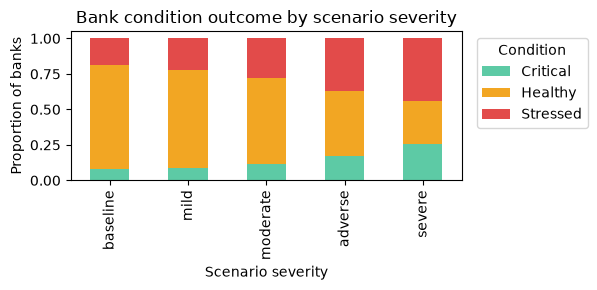

In [57]:
ct = pd.crosstab(panel_plot['scenario_severity_clean'], panel_plot['bank_condition_clean'], normalize='index')
ct = ct.reindex(severity_order)
ct.plot(kind='bar', stacked=True, figsize=(6,3), color=['#5DCAA5','#F2A623','#E24B4A'])
plt.title('Bank condition outcome by scenario severity')
plt.ylabel('Proportion of banks'); plt.xlabel('Scenario severity')
plt.legend(title='Condition', bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

### Bank condition by scenario severity — sanity check plot

- Stacked bar: proportion of banks in each condition (Healthy/Stressed/Critical) at each severity level (baseline → severe).
- Pattern is as expected: Healthy shrinks (~90% at baseline → ~50% at severe), Stressed and Critical both grow as severity increases.
- Confirms severity and condition labels are internally consistent — good validation that the simulation logic behaves sensibly.

Overall correlation between macro shocks and outcomes

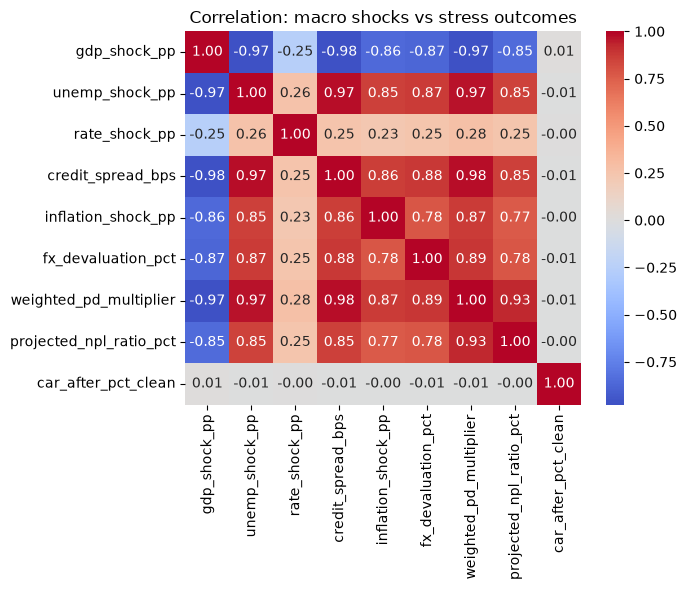

In [ ]:
numeric_cols = ['gdp_shock_pp','unemp_shock_pp','rate_shock_pp','credit_spread_bps',
                 'inflation_shock_pp','fx_devaluation_pct','weighted_pd_multiplier',
                 'projected_npl_ratio_pct','car_after_pct_clean']
corr = panel_plot[numeric_cols].corr()
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation: macro shocks vs stress outcomes')
plt.tight_layout()
plt.show()

### Correlation heatmap — macro shocks vs stress outcomes

- Macro shock variables (GDP, unemployment, inflation, FX, credit spread) and `weighted_pd_multiplier`/`projected_npl_ratio_pct` are all strongly correlated (0.77–0.98) — confirms these shocks move together and drive credit risk as expected.
- `gdp_shock_pp` is negatively correlated with the others (~-0.85 to -0.98) — makes sense if GDP shock is coded as negative for a downturn while other shocks are positive.
- `rate_shock_pp` stands out as weakly correlated with everything (~0.23–0.31) — worth a closer look, may be a genuinely independent lever or may need its own data check.
- **`car_after_pct_clean` shows ~0 correlation with every shock variable — a red flag, not a real finding.** This column still has the uncleaned `'999'`/`'-999'` sentinel noise (from the earlier plotting issue) inflating its variance and masking any real relationship. Re-run this heatmap after fully cleaning `car_after_pct` before trusting this column's row/column.

In [62]:
loan.info()
loan.head()

<class 'pandas.DataFrame'>
RangeIndex: 3006 entries, 0 to 3005
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   loan_id      3006 non-null   str    
 1   sector       3006 non-null   str    
 2   pd_annual    2969 non-null   str    
 3   lgd          2976 non-null   str    
 4   ead          3006 non-null   str    
 5   rwa          3006 non-null   float64
 6   loan_amount  3006 non-null   float64
dtypes: float64(2), str(5)
memory usage: 164.5 KB


,loan_id,sector,pd_annual,lgd,ead,rwa,loan_amount
0,LN_000001,Technology,0.00584,0.5415,2231852.0,1209754.0,2231852.0
1,LN_000002,Technology,0.0126,0.3865,6319210.0,4045442.0,6319210.0
2,LN_000003,Technology,0.0119,0.4048,4066620.0,2323031.0,4066620.0
3,LN_000004,Technology,0.01002,0.5537,418790.0,321615.0,418790.0
4,LN_000005,Technology,0.00313,0.607,3004580.0,2484953.0,3004580.0


In [65]:
print(loan["loan_id"].head(20).tolist())
print("Any lowercase loan_ids:", loan["loan_id"].str.contains(r'^ln_', case=False, regex=True).sum())
print("\nDuplicate rows:", loan.duplicated().sum())

['LN_000001', 'LN_000002', 'LN_000003', 'LN_000004', 'LN_000005', 'LN_000006', 'LN_000007', 'LN_000008', 'LN_000009', 'LN_000010', 'LN_000011', 'LN_000012', 'LN_000013', 'LN_000014', 'LN_000015', 'LN_000016', 'LN_000017', 'LN_000018', 'LN_000019', 'LN_000020']
Any lowercase loan_ids: 3006

Duplicate rows: 6


In [64]:
lowercase_ids = loan["loan_id"].str.contains(r'^ln_', case=True, regex=True)
print("Lowercase loan_ids:", lowercase_ids.sum())
print(loan.loc[lowercase_ids, "loan_id"].tolist())

Lowercase loan_ids: 8
['ln_000146', 'ln_000176', 'ln_000232', 'ln_000427', 'ln_000638', 'ln_002058', 'ln_002380', 'ln_002396']


### `loan_portfolio.csv` — loan_id format & duplicates

- **`loan_id`**: 8 rows use lowercase `ln_` prefix instead of `LN_` (e.g. `ln_000146`). Format inconsistency — matters if `loan_id` is ever used as a join/lookup key elsewhere, or for any case-sensitive matching.
- **Duplicate rows**: 6 exact duplicates — same handling as other files, drop before aggregating.

In [66]:
print(loan["sector"].value_counts(dropna=False))

sector
Retail            429
Telecom           356
Energy            344
Technology        334
Consumer          329
Healthcare        291
Real_Estate       265
Industrials       260
Utilities         147
Financials        109
ENERGY              8
Retail              7
consumer            7
Techno logy         6
Healthcare          6
energy              6
RETAIL              6
telecom             6
Consumr             6
technology          5
Retial              5
Consumer Goods      5
Tech                4
Enrgy               4
industrials         4
Telecomm            4
healthcare          3
real_estate         3
 Energy             3
Industrial          3
Industrails         3
Telcom              3
Tele Com            3
UTILITIES           3
Utility             3
Utilties            3
Financial           3
TECHNOLOGY          2
Health Care         2
HEALTHCARE          2
Real-Estate         2
Real Estate         2
Real  Estate        2
retail              2
utilities           2
Fin

### `loan_portfolio.csv` — `sector` fragmentation (worst so far)

- 10 real sectors (Retail, Telecom, Energy, Technology, Consumer, Healthcare, Real_Estate, Industrials, Utilities, Financials) fragmented into 20+ variants: casing (`ENERGY`, `RETAIL`), typos (`Retial`, `Consumr`, `Enrgy`, `Technlogy`, `Financails`), embedded whitespace (`Techno logy`), and alternate naming (`Consumer Goods` for Consumer, `Finance` for Financials, `Tech` for Technology).
- Highest-priority category — this column must match `macro_stress_scenarios.sector` exactly for the sector-level PD multiplier join to work; every unmapped spelling silently drops that loan's stress adjustment.

In [69]:
print("Unique sector spellings:", loan["sector"].nunique())

Unique sector spellings: 48


- `nunique()` = **48** distinct spellings for 10 real sectors 

In [70]:
mask_pd = loan["pd_annual"].astype(str).str.contains(r"[^\d\.\-]", regex=True, na=False)
print(f"pd_annual: {mask_pd.sum()} rows with non-numeric characters")
print(loan.loc[mask_pd, "pd_annual"].unique())

pd_annual: 94 rows with non-numeric characters
<StringArray>
[  '1.07%',   '1.72%',   '1.62%',   '1.91%',   '1.11%',   '0.95%',   '1.25%',
   '0.67%',   '2.28%',   '0.91%',   '0.72%',   '0.70%', 'MISSING',   '0.59%',
   '0.34%', 'missing', 'unknown',   '0.39%',   '1.39%',   '1.27%',   '1.23%',
   '2.55%',   '4.03%',   '1.16%',   '1.33%',   '2.43%',   '1.53%',   '0.75%',
   '1.20%',       ' ',   '1.28%',   '1.76%',   '2.30%',   '1.88%',   '0.61%',
   '0.76%',   '0.92%',   '1.83%',   '1.73%',   '3.62%',   '3.23%',   '2.58%',
   '1.19%',   '5.60%',   '2.46%',   '1.21%',   '0.44%',   '1.43%',   '0.84%',
   '1.89%',   '0.88%',   '0.82%',   '1.87%',   '0.49%',   '1.98%',   '0.89%',
   '0.79%',   '0.32%',   '0.65%',   '0.58%',   '1.00%',   '0.42%',   '0.85%']
Length: 63, dtype: str


### `loan_portfolio.csv` — `pd_annual` mixed issue

- 94 rows flagged as non-numeric — but two distinct problems bundled together:
  - Most are **percent-string encoding** (e.g. `'1.07%'`) representing the same PD as the decimal rows elsewhere (`0.0107`) — needs `%` stripped + divide by 100, not just symbol removal.
  - A smaller subset are true missing-value tokens (`'MISSING'`, `'missing'`, `'unknown'`, `' '`) — convert to `NaN`.
- Critical to separate these before cleaning: treating the percent-strings as plain missing would lose real data; blindly stripping `%` without dividing by 100 would produce invalid PD values > 1 (impossible for a probability).

In [71]:
print("pd_annual true NaN:", loan["pd_annual"].isna().sum())

pd_annual true NaN: 37


In [73]:
mask_lgd = loan["lgd"].astype(str).str.contains(r"[^\d\.\-]", regex=True, na=False)
print(f"lgd: {mask_lgd.sum()} rows with non-numeric characters")
print(loan.loc[mask_lgd, "lgd"].unique())
print("lgd true NaN:", loan["lgd"].isna().sum())

lgd: 21 rows with non-numeric characters
<StringArray>
['n.a.', 'not available']
Length: 2, dtype: str
lgd true NaN: 30


### `loan_portfolio.csv` — `lgd` missing values

- 21 rows with disguised missing tokens: `'n.a.'`, `'not available'` — no unit mismatch, single clean issue type.
- can resolve by converting both tokens to `NaN`.
- - **30** true `NaN` + **21** disguised tokens (`'n.a.'`, `'not available'`) = **51 rows** (~1.7% of 3,006) needing cleanup.

In [74]:
mask_ead = loan["ead"].astype(str).str.contains(r"[^\d\.\-]", regex=True, na=False)
print(f"ead: {mask_ead.sum()} rows with non-numeric characters")
print(loan.loc[mask_ead, "ead"].unique()[:15])
print("ead true NaN:", loan["ead"].isna().sum())

ead: 51 rows with non-numeric characters
<StringArray>
[ '9,521,421',  '4,662,420', '17,259,091',  '1,776,546', '16,321,316',
  '1,483,497',  '4,204,711',  '3,926,255',  '1,455,759',  '2,834,674',
  '9,623,974',  '4,278,512',  '1,110,624',  '2,053,882',  '7,408,081']
Length: 15, dtype: str
ead true NaN: 0


### `loan_portfolio.csv` — `ead` formatting

- 51 rows with comma-formatted numbers (e.g. `'9,521,421'`) — no `$` sign, no missing values (0 true NaN).

In [75]:
print("Negative loan_amount rows:", (loan["loan_amount"] < 0).sum())
print(loan.loc[loan["loan_amount"] < 0, "loan_amount"].tolist())

Negative loan_amount rows: 5
[-772839.0, -1130556.0, -1026034.0, -2767828.0, -2471609.0]


loan amount can't be in negative physically